<a href="https://colab.research.google.com/github/Sahana1909/Data-Visualization/blob/main/DVex4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving household_power_consumption.csv to household_power_consumption.csv


First 5 Rows
   index    Date     Time Global_active_power Global_reactive_power Voltage  \
0      0  1/1/07  0:00:00                2.58                 0.136  241.97   
1      1  1/1/07  0:01:00               2.552                   0.1  241.75   
2      2  1/1/07  0:02:00                2.55                   0.1  241.64   
3      3  1/1/07  0:03:00                2.55                   0.1  241.71   
4      4  1/1/07  0:04:00               2.554                   0.1  241.98   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             10.6              0              0             0.0  
1             10.4              0              0             0.0  
2             10.4              0              0             0.0  
3             10.4              0              0             0.0  
4             10.4              0              0             0.0  

Shape
(260640, 10)

Data Types
index                      int64
Date                      object
Time        

/tmp/ipykernel_2530/3239642753.py:74: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DateTime"] = pd.to_datetime(



Average Power Consumption by Hour
Hour
0     0.780775
1     0.634853
2     0.539581
3     0.515721
4     0.488086
5     0.526431
6     0.946130
7     1.534418
8     1.507545
9     1.353363
10    1.210740
11    1.110663
12    1.061976
13    1.007709
14    1.046805
15    1.001294
16    0.953496
17    1.073722
18    1.515065
19    2.085858
20    2.082602
21    2.199863
22    1.679499
23    1.086790
Name: Global_active_power, dtype: float64

Correlation Matrix
                       Global_active_power  Global_reactive_power   Voltage  \
Global_active_power               1.000000               0.279084 -0.375375   
Global_reactive_power             0.279084               1.000000 -0.101127   
Voltage                          -0.375375              -0.101127  1.000000   
Global_intensity                  0.998984               0.294772 -0.386419   
Sub_metering_1                    0.480525               0.159735 -0.217893   
Sub_metering_2                    0.470179               0.17830

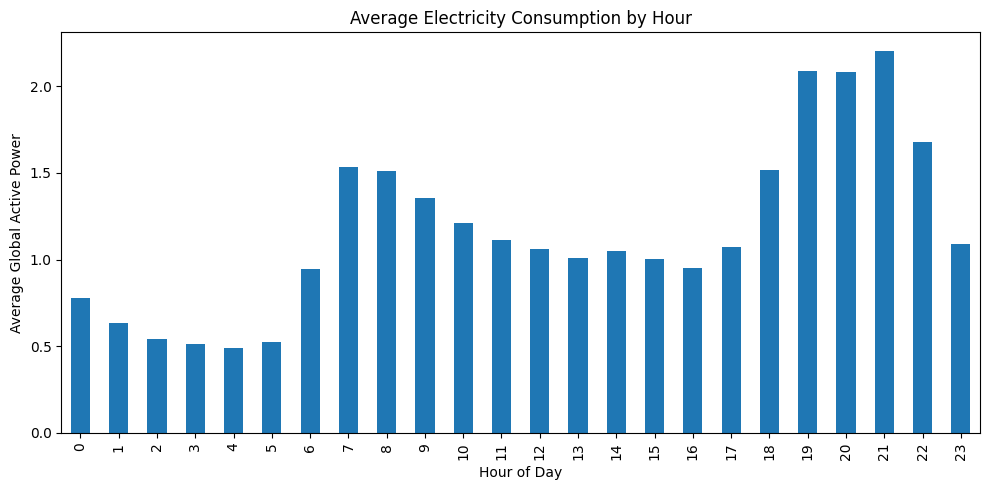

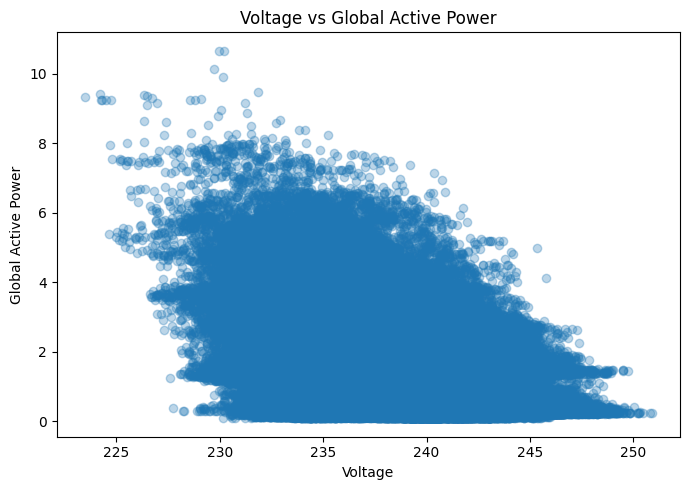

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv(
    "household_power_consumption.csv",
    engine="python",
    on_bad_lines="skip"
)

print("First 5 Rows")
print(df.head())

print("\nShape")
print(df.shape)

print("\nData Types")
print(df.dtypes)

print("\nStatistics")
print(df.describe())


# Convert numerical columns
num_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# Filtering
filtered = df[
    df["Global_active_power"] >
    df["Global_active_power"].mean()
]

print("\nFiltered Data - Above Average Power")
print(filtered.head())


# Sorting
sorted_df = df.sort_values(
    by="Global_active_power",
    ascending=False
)

print("\nSorted Data - Highest Power Consumption")
print(sorted_df.head())


# Statistical Analysis
for col in num_cols:

    print("\nColumn:", col)

    print("Mean:", df[col].mean())

    print("Median:", df[col].median())

    print("Mode:", df[col].mode()[0])

    print("Standard Deviation:", df[col].std())


# Date and Time
df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

df["Hour"] = df["DateTime"].dt.hour


# Grouping by Hour
grouped = df.groupby("Hour")[
    "Global_active_power"
].mean()

print("\nAverage Power Consumption by Hour")
print(grouped)


# Correlation
corr = df[num_cols].corr()

print("\nCorrelation Matrix")
print(corr)


# Bar Chart
plt.figure(figsize=(10,5))

grouped.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")

plt.title(
    "Average Electricity Consumption by Hour"
)

plt.tight_layout()
plt.show()


# Scatter Plot
plt.figure(figsize=(7,5))

plt.scatter(
    df["Voltage"],
    df["Global_active_power"],
    alpha=0.3
)

plt.xlabel("Voltage")
plt.ylabel("Global Active Power")

plt.title(
    "Voltage vs Global Active Power"
)

plt.tight_layout()
plt.show()